In [4]:
import json

candidates = []

with open("D:\\indiaruns\\AI-Recruiter-Intelligence\\data\\candidates.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))

print("Total candidates:", len(candidates))

Total candidates: 100000


How many candidates?

In [5]:
print(len(candidates))

100000


What fields exist?

In [6]:
candidates[0].keys()

dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])

What does a profile look like?

In [7]:
candidates[0]["profile"]

{'anonymized_name': 'Ira Vora',
 'headline': 'Backend Engineer | SQL, Spark, Cloud',
 'summary': "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
 'location': 'Toronto',
 'country': 'Canada',
 'years_of_experience': 6.9,
 'current_title': 'Backend Engineer',
 'current_company': 'Mindtree',
 'current_company_size': '10001+',
 'current_industry': 'IT Services'}

What do skills look like?

In [8]:
candidates[0]["skills"]

[{'name': 'Tailwind',
  'proficiency': 'intermediate',
  'endorsements': 3,
  'duration_months': 13},
 {'name': 'NLP',
  'proficiency': 'advanced',
  'endorsements': 37,
  'duration_months': 26},
 {'name': 'Image Classification',
  'proficiency': 'advanced',
  'endorsements': 7,
  'duration_months': 40},
 {'name': 'Fine-tuning LLMs',
  'proficiency': 'advanced',
  'endorsements': 21,
  'duration_months': 36},
 {'name': 'Weights & Biases',
  'proficiency': 'intermediate',
  'endorsements': 13,
  'duration_months': 30},
 {'name': 'Speech Recognition',
  'proficiency': 'advanced',
  'endorsements': 52,
  'duration_months': 33},
 {'name': 'Photoshop',
  'proficiency': 'intermediate',
  'endorsements': 8,
  'duration_months': 24},
 {'name': 'TTS',
  'proficiency': 'advanced',
  'endorsements': 56,
  'duration_months': 60},
 {'name': 'LoRA',
  'proficiency': 'intermediate',
  'endorsements': 0,
  'duration_months': 28},
 {'name': 'Apache Beam',
  'proficiency': 'intermediate',
  'endorsement

What are the behavioral signals?

In [9]:
candidates[0]["redrob_signals"]

{'profile_completeness_score': 86.9,
 'signup_date': '2025-10-16',
 'last_active_date': '2026-05-20',
 'open_to_work_flag': True,
 'profile_views_received_30d': 23,
 'applications_submitted_30d': 2,
 'recruiter_response_rate': 0.34,
 'avg_response_time_hours': 177.8,
 'skill_assessment_scores': {'NLP': 38.8,
  'Image Classification': 64.8,
  'Fine-tuning LLMs': 41.6,
  'Speech Recognition': 53.7},
 'connection_count': 356,
 'endorsements_received': 35,
 'notice_period_days': 60,
 'expected_salary_range_inr_lpa': {'min': 18.7, 'max': 36.1},
 'preferred_work_mode': 'onsite',
 'willing_to_relocate': False,
 'github_activity_score': 9.2,
 'search_appearance_30d': 249,
 'saved_by_recruiters_30d': 4,
 'interview_completion_rate': 0.71,
 'offer_acceptance_rate': 0.58,
 'verified_email': True,
 'verified_phone': True,
 'linkedin_connected': False}

Experience Distribution

In [10]:
years = []

for c in candidates:
    profile = c.get("profile", {})
    years.append(profile.get("years_of_experience", 0))

import pandas as pd

exp = pd.Series(years)

exp.describe()

count    100000.000000
mean          7.166319
std           3.824551
min           1.000000
25%           3.900000
50%           6.800000
75%           9.900000
max          16.900000
dtype: float64

<Axes: >

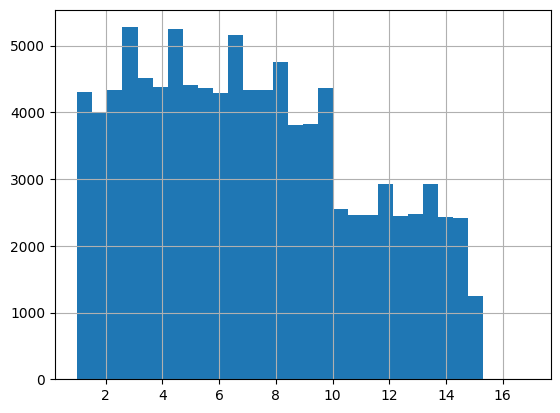

In [11]:
exp.hist(bins=30)

Top Skills

In [12]:
from collections import Counter

skill_counter = Counter()

for c in candidates:
    for s in c["skills"]:
        skill_counter[s["name"]] += 1

skill_counter.most_common(50)

[('HTML', 12246),
 ('Databricks', 12244),
 ('Redux', 12222),
 ('Terraform', 12187),
 ('Angular', 12173),
 ('Figma', 12157),
 ('Salesforce CRM', 12157),
 ('Vue.js', 12142),
 ('Sales', 12138),
 ('Accounting', 12136),
 ('Agile', 12135),
 ('Kafka', 12114),
 ('Excel', 12109),
 ('BigQuery', 12108),
 ('CI/CD', 12108),
 ('Project Management', 12106),
 ('Airflow', 12105),
 ('AWS', 12104),
 ('Flask', 12104),
 ('Scrum', 12083),
 ('Illustrator', 12072),
 ('Kubernetes', 12071),
 ('ETL', 12068),
 ('CSS', 12065),
 ('Docker', 12062),
 ('Next.js', 12058),
 ('Apache Beam', 12054),
 ('Java', 12049),
 ('Go', 12049),
 ('TypeScript', 12048),
 ('JavaScript', 12047),
 ('dbt', 12046),
 ('REST APIs', 12040),
 ('Spark', 12038),
 ('Marketing', 12037),
 ('Tally', 12030),
 ('GraphQL', 12027),
 ('Snowflake', 12027),
 ('Webpack', 12026),
 ('Six Sigma', 11991),
 ('SEO', 11990),
 ('SAP', 11989),
 ('GCP', 11983),
 ('PostgreSQL', 11983),
 ('Rust', 11960),
 ('Apache Flink', 11958),
 ('gRPC', 11957),
 ('Content Writing', 1

Industries

In [13]:
industry_counter = Counter()

for c in candidates:
    industry = c["profile"].get("current_industry")

    if industry:
        industry_counter[industry] += 1

industry_counter.most_common(20)

[('IT Services', 29881),
 ('Software', 22417),
 ('Manufacturing', 22305),
 ('Conglomerate', 7571),
 ('Paper Products', 7467),
 ('Fintech', 2808),
 ('Food Delivery', 2514),
 ('E-commerce', 1529),
 ('Consulting', 1274),
 ('EdTech', 610),
 ('SaaS', 328),
 ('AI/ML', 278),
 ('AdTech', 172),
 ('Transportation', 162),
 ('Insurance Tech', 155),
 ('Gaming', 149),
 ('HealthTech', 147),
 ('HealthTech AI', 68),
 ('Conversational AI', 62),
 ('AI Services', 42)]

All Redrob Signals

In [14]:
candidates[0]["redrob_signals"].keys()

dict_keys(['profile_completeness_score', 'signup_date', 'last_active_date', 'open_to_work_flag', 'profile_views_received_30d', 'applications_submitted_30d', 'recruiter_response_rate', 'avg_response_time_hours', 'skill_assessment_scores', 'connection_count', 'endorsements_received', 'notice_period_days', 'expected_salary_range_inr_lpa', 'preferred_work_mode', 'willing_to_relocate', 'github_activity_score', 'search_appearance_30d', 'saved_by_recruiters_30d', 'interview_completion_rate', 'offer_acceptance_rate', 'verified_email', 'verified_phone', 'linkedin_connected'])

Missing Values Analysis

In [15]:
columns = [
    "profile",
    "career_history",
    "education",
    "skills",
    "certifications",
    "languages",
    "redrob_signals"
]

for col in columns:
    missing = sum(
        1 for c in candidates
        if not c.get(col)
    )

    print(
        f"{col}: {missing} "
        f"({missing/len(candidates)*100:.2f}%)"
    )

profile: 0 (0.00%)
career_history: 0 (0.00%)
education: 0 (0.00%)
skills: 0 (0.00%)
certifications: 75019 (75.02%)
languages: 0 (0.00%)
redrob_signals: 0 (0.00%)


Skills per candidate.

In [16]:
skill_counts = []

for c in candidates:
    skill_counts.append(len(c["skills"]))

pd.Series(skill_counts).describe()

count    100000.00000
mean          9.60302
std           3.31163
min           5.00000
25%           7.00000
50%           9.00000
75%          11.00000
max          23.00000
dtype: float64